In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import re
from pathlib import Path

def parse_log_file(filepath):
    """Parse a single log file and extract the data."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract shoe composition
    shoe_pattern = r"Rank (\d+|A): (\d+)"
    shoe_matches = re.findall(shoe_pattern, content)
    shoe_composition = {k: int(v) for k, v in shoe_matches}
    
    # Extract reference values
    ref_pattern = r"Reference value.*depth=(\d+), gap=([\d.e-]+)\): ([\d.-]+)"
    ref_match = re.search(ref_pattern, content)
    ref_depth = int(ref_match.group(1)) if ref_match else None
    ref_gap = float(ref_match.group(2)) if ref_match else None
    ref_value = float(ref_match.group(3)) if ref_match else None
    
    # Extract algorithm runtimes
    recursive_pattern = r"RECURSIVE: ([\d.-]+) \(runtime: ([\d.]+) s\)"
    combo_pattern = r"COMBO:\s+([\d.-]+) \(runtime: ([\d.]+) s\)"
    
    recursive_match = re.search(recursive_pattern, content)
    combo_match = re.search(combo_pattern, content)
    
    ref_recursive_ev = float(recursive_match.group(1)) if recursive_match else None
    ref_recursive_runtime = float(recursive_match.group(2)) if recursive_match else None
    ref_combo_ev = float(combo_match.group(1)) if combo_match else None
    ref_combo_runtime = float(combo_match.group(2)) if combo_match else None
    
    # Extract table data
    rows = []
    # Pattern for algorithm sections
    algo_sections = re.split(r"Algorithm: (RECURSIVE|COMBO)", content)
    
    for i in range(1, len(algo_sections), 2):
        algo = algo_sections[i]
        section = algo_sections[i + 1]
        
        # Parse table rows
        row_pattern = r"(\d+)\s+([\d.e+-]+)\s+([\d.]+)\s+([\d.-]+)\s+([\d.-]+)\s+([\d.-]+)\s+([\d.-]+)"
        matches = re.findall(row_pattern, section)
        
        for match in matches:
            rows.append({
                'algorithm': algo,
                'depth': int(match[0]),
                'gap_target': float(match[1]),
                'runtime': float(match[2]),
                'ev': float(match[3]),
                'ev_min': float(match[4]),
                'ev_max': float(match[5]),
                'error': float(match[6])
            })
    
    df = pd.DataFrame(rows)
    
    metadata = {
        'shoe_composition': shoe_composition,
        'ref_depth': ref_depth,
        'ref_gap': ref_gap,
        'ref_value': ref_value,
        'ref_recursive_ev': ref_recursive_ev,
        'ref_recursive_runtime': ref_recursive_runtime,
        'ref_combo_ev': ref_combo_ev,
        'ref_combo_runtime': ref_combo_runtime,
        'filepath': str(filepath)
    }
    
    return df, metadata

def load_all_logs(log_dir="../logs/shoe_edge_test"):
    """Load all log files from directory."""
    log_path = Path(log_dir)
    all_dfs = []
    all_metadata = []
    
    for log_file in sorted(log_path.glob("log_*.txt")):
        try:
            df, metadata = parse_log_file(log_file)
            df['log_file'] = log_file.name
            all_dfs.append(df)
            all_metadata.append(metadata)
        except Exception as e:
            print(f"Error parsing {log_file}: {e}")
    
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
    else:
        combined_df = pd.DataFrame()
    
    return combined_df, all_metadata

# Load data
df, metadata_list = load_all_logs()
print(f"Loaded {len(metadata_list)} log files")
print(f"Total rows: {len(df)}")
df.head(10)

Loaded 20 log files
Total rows: 1706


,algorithm,depth,gap_target,runtime,ev,ev_min,ev_max,error,log_file
0,COMBO,2.0,0.10000,0.399,9.717840,9.657395,10.773941,0.023756,log_0000.txt
1,COMBO,2.0,0.03000,0.551,10.135647,10.118448,10.313047,0.441562,log_0000.txt
2,COMBO,2.0,0.01000,0.692,10.056562,10.052617,10.147512,0.362477,log_0000.txt
3,COMBO,2.0,0.00300,1.030,10.064404,10.062850,10.082397,0.370319,log_0000.txt
4,COMBO,2.0,0.00100,1.128,10.627861,10.627589,10.631761,0.933776,log_0000.txt
5,COMBO,2.0,0.00030,1.342,9.852414,9.852351,9.853394,0.158330,log_0000.txt
6,COMBO,2.0,0.00010,1.450,9.863771,9.863761,9.864057,0.169687,log_0000.txt
7,COMBO,2.0,0.00003,1.611,10.065247,10.065243,10.065340,0.371163,log_0000.txt
8,COMBO,2.0,0.00001,1.841,10.164451,10.164448,10.164475,0.470366,log_0000.txt
9,COMBO,3.0,0.10000,0.671,9.697834,9.608722,11.182365,0.003749,log_0000.txt


In [3]:
# Add absolute error column before aggregation
df['abs_error'] = df['error'].abs()

# Aggregate data across log files (mean values)
df_agg = df.groupby(['algorithm', 'depth', 'gap_target']).agg({
    'runtime': 'mean',
    'ev': 'mean',
    'error': 'mean',
    'abs_error': 'mean',  # Average of absolute errors
    'ev_min': 'mean',
    'ev_max': 'mean'
}).reset_index()

df_agg

,algorithm,depth,gap_target,runtime,ev,error,abs_error,ev_min,ev_max
0,COMBO,2.0,0.00001,3.564368,3.612403,0.268018,0.278806,3.612398,3.612449
1,COMBO,2.0,0.00003,3.407316,3.518294,0.173910,0.207380,3.518277,3.518474
2,COMBO,2.0,0.00010,3.236842,3.613104,0.268719,0.344237,3.613054,3.613724
3,COMBO,2.0,0.00030,2.982737,3.558610,0.214225,0.270817,3.558395,3.560824
4,COMBO,2.0,0.00100,2.690895,3.709255,0.364870,0.415383,3.708372,3.718121
...,...,...,...,...,...,...,...,...,...
85,COMBO,11.0,0.00100,7.878947,3.342343,-0.002042,0.002042,3.341519,3.351246
86,COMBO,11.0,0.00300,6.569316,3.338151,-0.006233,0.006268,3.335387,3.366108
87,COMBO,11.0,0.01000,5.653368,3.323955,-0.020430,0.020525,3.314345,3.425083
88,COMBO,11.0,0.03000,4.030368,3.278274,-0.066110,0.067713,3.238431,3.675326


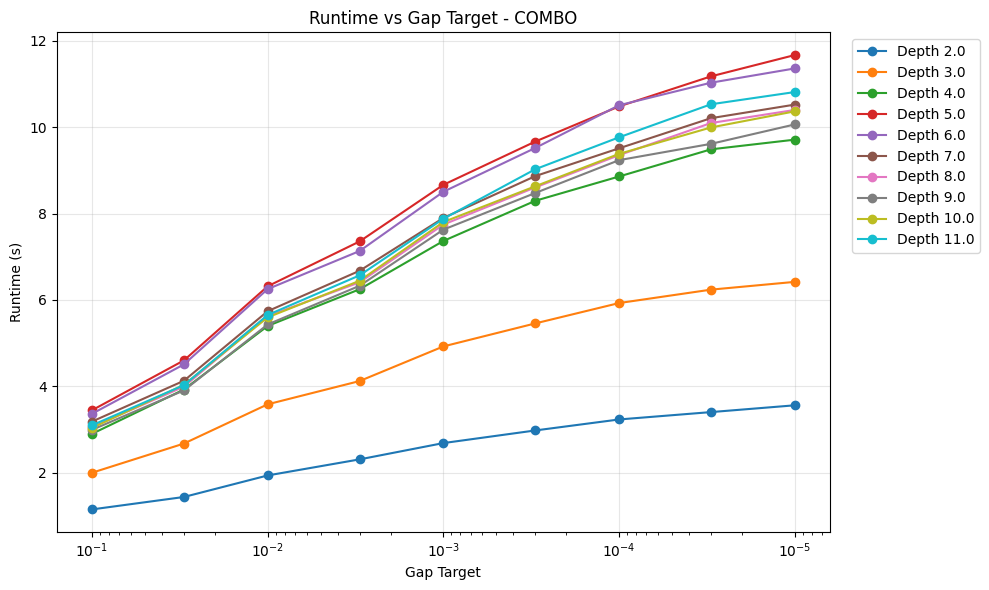

In [4]:
# Plot 1: Runtime vs Gap Target for COMBO algorithm
fig, ax = plt.subplots(figsize=(10, 6))

algo_data = df_agg[df_agg['algorithm'] == 'COMBO']

for depth in sorted(algo_data['depth'].unique()):
    depth_data = algo_data[algo_data['depth'] == depth]
    ax.plot(depth_data['gap_target'], depth_data['runtime'], 'o-', label=f'Depth {depth}')

ax.set_xscale('log')
ax.set_xlabel('Gap Target')
ax.set_ylabel('Runtime (s)')
ax.set_title('Runtime vs Gap Target - COMBO')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

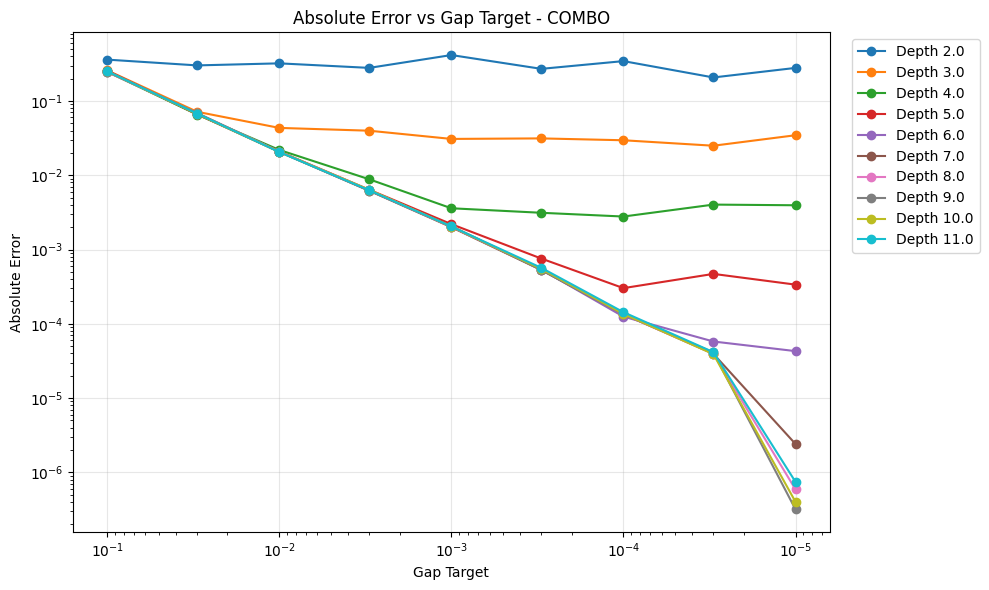

In [5]:
# Plot 2: Absolute Error vs Gap Target for COMBO algorithm
fig, ax = plt.subplots(figsize=(10, 6))

algo_data = df_agg[df_agg['algorithm'] == 'COMBO']

for depth in sorted(algo_data['depth'].unique()):
    depth_data = algo_data[algo_data['depth'] == depth]
    ax.plot(depth_data['gap_target'], depth_data['abs_error'], 'o-', label=f'Depth {depth}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Gap Target')
ax.set_ylabel('Absolute Error')
ax.set_title('Absolute Error vs Gap Target - COMBO')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

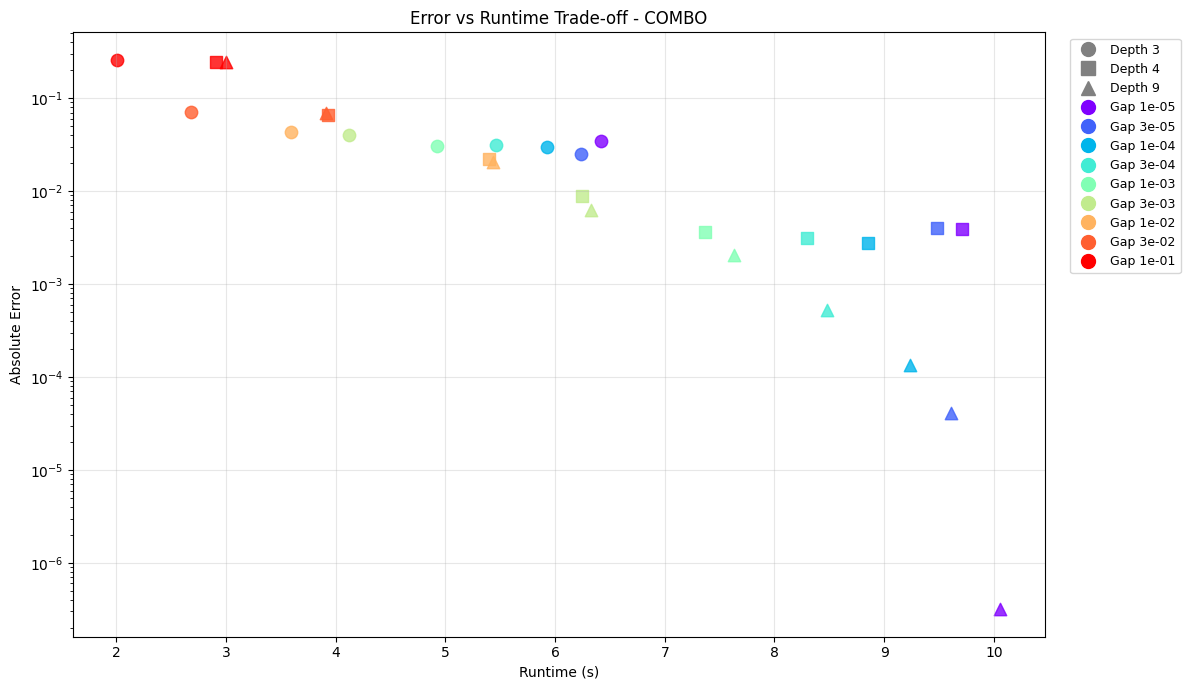

In [6]:
# Plot 3: Error vs Runtime (trade-off visualization) for COMBO
fig, ax = plt.subplots(figsize=(12, 7))

df_target = df_agg[df_agg['depth'].isin([3, 4, 9])]
algo_data = df_target[df_target['algorithm'] == 'COMBO']

# Define markers for different depths
depth_markers = {3: 'o', 4: 's', 9: '^'}

# Get unique gap targets and create color map
gap_targets = sorted(algo_data['gap_target'].unique())
colors = plt.cm.rainbow(np.linspace(0, 1, len(gap_targets)))
gap_color_map = dict(zip(gap_targets, colors))

# Plot each combination of depth and gap_target
for depth in sorted(algo_data['depth'].unique()):
    for gap in gap_targets:
        subset = algo_data[(algo_data['depth'] == depth) & (algo_data['gap_target'] == gap)]
        if len(subset) > 0:
            ax.scatter(
                subset['runtime'], subset['abs_error'],
                c=[gap_color_map[gap]], 
                marker=depth_markers[depth],
                s=80, alpha=0.8,
                label=f'D{depth}, gap={gap:.0e}'
            )

ax.set_xlabel('Runtime (s)')
ax.set_ylabel('Absolute Error')
ax.set_yscale('log')
ax.set_title('Error vs Runtime Trade-off - COMBO')
ax.grid(True, alpha=0.3)

# Create custom legend
from matplotlib.lines import Line2D

# Legend for depths (shapes)
depth_handles = [Line2D([0], [0], marker=m, color='gray', linestyle='None', 
                        markersize=10, label=f'Depth {d}') 
                 for d, m in depth_markers.items()]

# Legend for gaps (colors) - show subset
gap_handles = [Line2D([0], [0], marker='o', color=gap_color_map[g], linestyle='None',
                      markersize=10, label=f'Gap {g:.0e}') 
               for g in gap_targets]  # Show every other gap to save space

ax.legend(handles=depth_handles + gap_handles, 
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

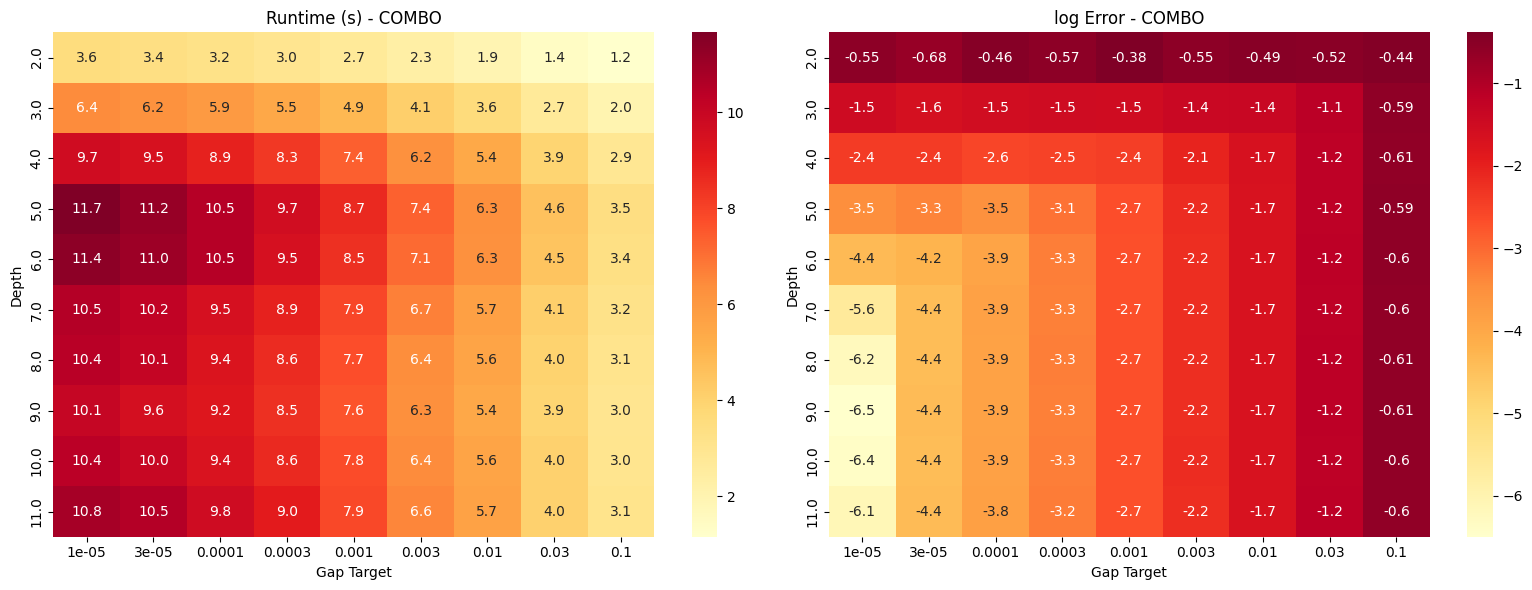

In [7]:
# Plot 4: Heatmap of Runtime and Error by Depth and Gap Target for COMBO
algo_data = df_agg[df_agg['algorithm'] == 'COMBO']

# Pivot for heatmap
runtime_pivot = algo_data.pivot(index='depth', columns='gap_target', values='runtime')
error_pivot = algo_data.pivot(index='depth', columns='gap_target', values='abs_error')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Runtime heatmap
sns.heatmap(runtime_pivot, ax=axes[0], annot=True, fmt='.1f', cmap='YlOrRd')
axes[0].set_title('Runtime (s) - COMBO')
axes[0].set_xlabel('Gap Target')
axes[0].set_ylabel('Depth')

# Error heatmap
sns.heatmap(np.log(error_pivot) / np.log(10), ax=axes[1], annot=True, fmt='.2', cmap='YlOrRd')
axes[1].set_title('log Error - COMBO')
axes[1].set_xlabel('Gap Target')
axes[1].set_ylabel('Depth')

plt.tight_layout()
plt.show()

In [8]:
# Summary: Reference values and runtimes from all log files
ref_df = pd.DataFrame(metadata_list)
print("Reference Computation Summary:")
print("=" * 60)
print(f"Number of log files: {len(ref_df)}")
print(f"\nReference RECURSIVE Runtime:")
print(f"  Mean: {ref_df['ref_recursive_runtime'].mean():.2f} s")
print(f"  Std:  {ref_df['ref_recursive_runtime'].std():.2f} s")
print(f"\nReference COMBO Runtime:")
print(f"  Mean: {ref_df['ref_combo_runtime'].mean():.2f} s")
print(f"  Std:  {ref_df['ref_combo_runtime'].std():.2f} s")
print(f"\nReference EV Statistics:")
print(f"  Mean: {ref_df['ref_value'].mean():.6f}")
print(f"  Std:  {ref_df['ref_value'].std():.6f}")

# Show shoe compositions
ref_df[['filepath', 'ref_value', 'ref_recursive_runtime', 'ref_combo_runtime']]

Reference Computation Summary:
Number of log files: 20

Reference RECURSIVE Runtime:
  Mean: 52.75 s
  Std:  65.89 s

Reference COMBO Runtime:
  Mean: 10.06 s
  Std:  9.92 s

Reference EV Statistics:
  Mean: 3.344385
  Std:  4.867959


,filepath,ref_value,ref_recursive_runtime,ref_combo_runtime
0,../logs/shoe_edge_test/log_0000.txt,9.694084,19.306,5.375
1,../logs/shoe_edge_test/log_0001.txt,-0.994962,136.457,23.242
2,../logs/shoe_edge_test/log_0002.txt,4.854077,20.626,5.781
3,../logs/shoe_edge_test/log_0003.txt,5.107391,223.987,35.879
4,../logs/shoe_edge_test/log_0004.txt,7.815448,20.215,5.055
5,../logs/shoe_edge_test/log_0005.txt,4.863139,44.494,9.456
6,../logs/shoe_edge_test/log_0006.txt,-2.215693,70.503,13.050
7,../logs/shoe_edge_test/log_0007.txt,-3.505938,15.668,4.924
8,../logs/shoe_edge_test/log_0008.txt,6.830858,17.613,5.001
9,../logs/shoe_edge_test/log_0009.txt,14.104217,12.944,4.066


In [9]:
# Check difference between reference RECURSIVE and COMBO algorithms
ref_df = pd.DataFrame(metadata_list)

ref_df['ev_diff'] = (ref_df['ref_recursive_ev'] - ref_df['ref_combo_ev']).abs()
ref_df['ev_diff_pct'] = ref_df['ev_diff'] / ref_df['ref_value'].abs() * 100

print("Difference between RECURSIVE and COMBO reference values:")
print("=" * 60)
print(f"Mean absolute difference: {ref_df['ev_diff'].mean():.8f}")
print(f"Max absolute difference:  {ref_df['ev_diff'].max():.8f}")
print(f"Std absolute difference:  {ref_df['ev_diff'].std():.8f}")
print()
print(f"Mean % difference: {ref_df['ev_diff_pct'].mean():.6f}%")
print(f"Max % difference:  {ref_df['ev_diff_pct'].max():.6f}%")

# Flag any suspicious differences (e.g., > 0.01%)
threshold_pct = 0.02
suspicious = ref_df[ref_df['ev_diff_pct'] > threshold_pct]
if len(suspicious) > 0:
    print(f"\n⚠️  WARNING: {len(suspicious)} log files have difference > {threshold_pct}%:")
    print(suspicious[['filepath', 'ref_recursive_ev', 'ref_combo_ev', 'ev_diff', 'ev_diff_pct']])
else:
    print(f"\n✓ All differences are within {threshold_pct}% threshold")

# Show distribution
ref_df[['filepath', 'ref_recursive_ev', 'ref_combo_ev', 'ev_diff', 'ev_diff_pct']]

Difference between RECURSIVE and COMBO reference values:
Mean absolute difference: 0.00010602
Max absolute difference:  0.00044810
Std absolute difference:  0.00013838

Mean % difference: 0.004050%
Max % difference:  0.033678%

⚠️  WARNING: 1 log files have difference > 0.02%:
                               filepath  ref_recursive_ev  ref_combo_ev  \
10  ../logs/shoe_edge_test/log_0010.txt         -0.140953        -0.141   

     ev_diff  ev_diff_pct  
10  0.000047     0.033678  


,filepath,ref_recursive_ev,ref_combo_ev,ev_diff,ev_diff_pct
0,../logs/shoe_edge_test/log_0000.txt,9.694085,9.694000,8.498000e-05,8.766171e-04
1,../logs/shoe_edge_test/log_0001.txt,-0.994962,-0.995000,3.838000e-05,3.857435e-03
2,../logs/shoe_edge_test/log_0002.txt,4.854077,4.854000,7.658000e-05,1.577643e-03
3,../logs/shoe_edge_test/log_0003.txt,5.107391,5.107000,3.908700e-04,7.653027e-03
4,../logs/shoe_edge_test/log_0004.txt,7.815448,7.815000,4.481000e-04,5.733517e-03
5,../logs/shoe_edge_test/log_0005.txt,4.863139,4.863000,1.385200e-04,2.848366e-03
6,../logs/shoe_edge_test/log_0006.txt,-2.215693,-2.216000,3.065600e-04,1.383585e-02
7,../logs/shoe_edge_test/log_0007.txt,-3.505938,-3.506000,6.172000e-05,1.760442e-03
8,../logs/shoe_edge_test/log_0008.txt,6.830858,6.831000,1.421900e-04,2.081583e-03
9,../logs/shoe_edge_test/log_0009.txt,14.104217,14.104000,2.167900e-04,1.537058e-03


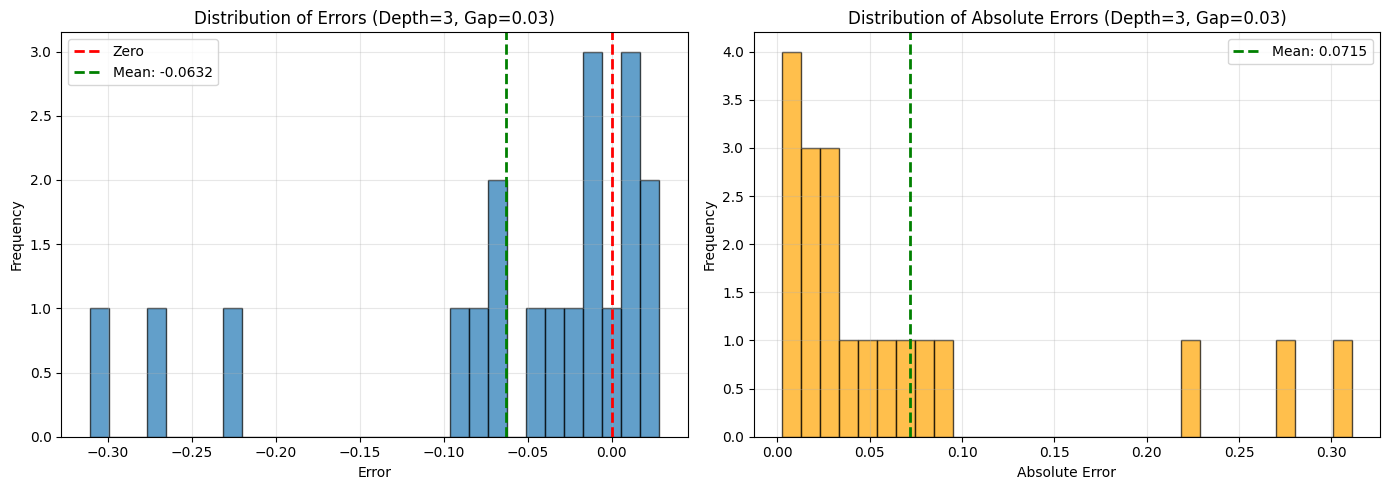

Error statistics for Depth=3, Gap=0.03:
  N samples: 19
  Mean error: -0.063244
  Std error:  0.099933
  Mean |error|: 0.071528
  Max |error|:  0.310866


In [10]:
# Histogram of errors for depth=3, gap=0.03
target_depth = 3
target_gap = 0.03

# Filter data for specific depth and gap
filtered_df = df[(df['depth'] == target_depth) & 
                 (df['gap_target'] == target_gap) & 
                 (df['algorithm'] == 'COMBO')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of signed errors
axes[0].hist(filtered_df['error'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0].axvline(x=filtered_df['error'].mean(), color='green', linestyle='--', linewidth=2, 
                label=f'Mean: {filtered_df["error"].mean():.4f}')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of Errors (Depth={target_depth}, Gap={target_gap})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of absolute errors
axes[1].hist(filtered_df['abs_error'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=filtered_df['abs_error'].mean(), color='green', linestyle='--', linewidth=2,
                label=f'Mean: {filtered_df["abs_error"].mean():.4f}')
axes[1].set_xlabel('Absolute Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Distribution of Absolute Errors (Depth={target_depth}, Gap={target_gap})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Error statistics for Depth={target_depth}, Gap={target_gap}:")
print(f"  N samples: {len(filtered_df)}")
print(f"  Mean error: {filtered_df['error'].mean():.6f}")
print(f"  Std error:  {filtered_df['error'].std():.6f}")
print(f"  Mean |error|: {filtered_df['abs_error'].mean():.6f}")
print(f"  Max |error|:  {filtered_df['abs_error'].max():.6f}")